In [5]:
ls reports/seed-42/

report_esm2_t12_35M_UR50D_float32_seed-42_pr_curve.json
report_esm2_t12_35M_UR50D_ubinary_seed-42_pr_curve.json
report_esm2_t30_150M_UR50D_float32_seed-42_pr_curve.json
report_esm2_t30_150M_UR50D_ubinary_seed-42_pr_curve.json
report_esm2_t33_650M_UR50D_float32_seed-42_pr_curve.json
report_esm2_t33_650M_UR50D_ubinary_seed-42_pr_curve.json
report_esm2_t36_3B_UR50D_float32_seed-42_pr_curve.json
report_esm2_t36_3B_UR50D_ubinary_seed-42_pr_curve.json
report_esm2_t48_15B_UR50D_float32_seed-42_pr_curve.json
report_esm2_t48_15B_UR50D_ubinary_seed-42_pr_curve.json
report_esm2_t6_8M_UR50D_float32_seed-42_pr_curve.json
report_esm2_t6_8M_UR50D_ubinary_seed-42_pr_curve.json
report_esmc_300m_float32_seed-42_pr_curve.json
report_esmc_300m_ubinary_seed-42_pr_curve.json
report_esmc_600m_float32_seed-42_pr_curve.json
report_esmc_600m_ubinary_seed-42_pr_curve.json
report_prot_t5_xl_half_uniref50-enc_float32_seed-42_pr_curve.json
report_prot_t5_xl_half_uniref50-enc_ubinary_seed-42_pr_curve.json


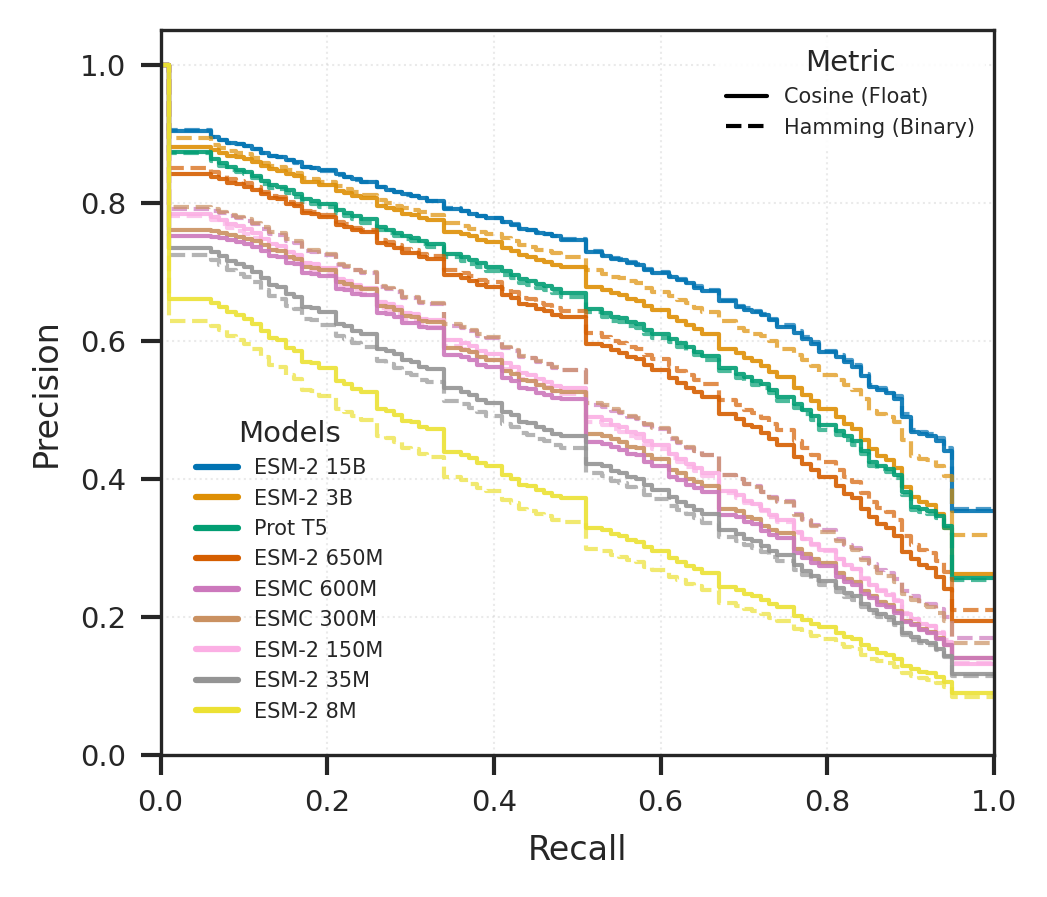

In [10]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
import re
import seaborn as sns
from pathlib import Path

# --- 1. NATURE STYLE SETUP ---
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'legend.title_fontsize': 7,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.8,
    'pdf.fonttype': 42, 
    'ps.fonttype': 42
})

# --- 2. HELPER: NAME SHORTENER ---
def clean_model_name(raw_name: str) -> str:
    """
    Converts raw file names to publication-ready short names.
    Example: 'esm2_t33_650M_UR50D' -> 'ESM-2 650M'
    """
    match = re.search(r'esm2_t\d+_([0-9]+[MB])_UR50D', raw_name)
    if match:
        return f"ESM-2 {match.group(1)}"
    
    if 'esmc' in raw_name.lower():
        size_match = re.search(r'(\d+m)', raw_name.lower())
        size = size_match.group(1).upper() if size_match else ""
        return f"ESMC {size}"

    if 'prot_t5' in raw_name.lower():
        return 'Prot T5'
    
    return raw_name.replace('_', ' ').title()

# --- 3. DATA LOADING ---
search_path = 'reports/seed-42/report_*.json'
files = glob.glob(search_path)

results = []
model_max_score = {} 

for filepath in files:
    with open(filepath, 'r') as f:
        data = json.load(f)
        
    filename = os.path.basename(filepath)
    is_binary = 'ubinary' in filename
    
    match = re.search(r'report_(.*?)_(float32|ubinary)', filename)
    raw_base_name = match.group(1) if match else "Unknown"
    
    display_name = clean_model_name(raw_base_name)
    auprc = data.get('auprc', 0)
    
    if display_name not in model_max_score:
        model_max_score[display_name] = auprc
    else:
        model_max_score[display_name] = max(model_max_score[display_name], auprc)

    results.append({
        'recall': data['recall'],
        'precision': data['precision'],
        'auprc': auprc,
        'is_binary': is_binary,
        'display_name': display_name
    })

# --- 4. SORTING & COLORS ---
results.sort(key=lambda x: x['auprc'], reverse=True)

sorted_model_names = sorted(model_max_score.keys(), 
                            key=lambda x: model_max_score[x], 
                            reverse=True)

palette = sns.color_palette("colorblind", len(sorted_model_names))
color_dict = {name: palette[i] for i, name in enumerate(sorted_model_names)}

# --- 5. PLOTTING ---
fig, ax = plt.subplots(figsize=(3.5, 3.0), dpi=300)

for res in results:
    linestyle = '--' if res['is_binary'] else '-'
    alpha = 0.9 if not res['is_binary'] else 0.7
    color = color_dict.get(res['display_name'], 'black')
    
    ax.plot(res['recall'], 
            res['precision'], 
            linestyle=linestyle,
            linewidth=1.0,
            drawstyle='steps-post', 
            color=color,
            alpha=alpha)

# --- 6. FORMATTING ---
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# --- 7. LEGEND (SWAPPED) ---

# Legend 1: Models (Now Lower Left)
# Lower left is usually empty in PR curves, so no background needed (frameon=False)
model_handles = [Line2D([0], [0], color=color_dict[name], lw=1.5) for name in sorted_model_names]

first_legend = ax.legend(model_handles, sorted_model_names, 
                         title="Models",
                         loc='lower left',    # SWAPPED
                         fontsize=5.0,
                         bbox_to_anchor=(0.02, 0.02),
                         frameon=False)
ax.add_artist(first_legend)

# Legend 2: Metrics (Now Upper Right)
# Upper right usually has data lines, so we add a background (frameon=True)
style_handles = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'),
    Line2D([0], [0], color='black', lw=1, linestyle='--')
]
style_labels = ['Cosine (Float)', 'Hamming (Binary)']

ax.legend(style_handles, style_labels, 
          title="Metric",
          loc='upper right',   # SWAPPED
          bbox_to_anchor=(1.0, 1.0),
          frameon=True,
          fontsize=5.0,
          framealpha=0.9,      # High opacity to block lines underneath
          edgecolor='white')   # Invisible border

plt.tight_layout()
plt.savefig("pfam_pr_curve.pdf", dpi=600, bbox_inches='tight')
plt.savefig("pfam_pr_curve.png", dpi=600, bbox_inches='tight')

plt.show()

In [8]:
def plot_cluster_variance_jupyter(json_paths):
    """Plot the variance of each cluster."""
    
    def short_name(model):
        if 'esm2' in model:
            return model.split('/')[-1].replace('_UR50D', '')
        if 'esmc' in model:
            return model.replace('esmc_', 'ESM-C ')
        if 'prot_t5' in model:
            return 'Prot-T5-XL'
        return model.split('/')[-1][:20]

    data_list = [json.loads(Path(p).read_text()) for p in json_paths]

    if len(data_list) == 1:
        data = data_list[0]
        cos = data['cosine_similarity']['per_cluster']
        ham = data['hamming_distance']['per_cluster']
        var_cos = [v['variance'] for v in cos.values()]
        var_ham = [v['variance'] for v in ham.values()]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        
        # Cosine Similarity Histogram
        ax1.hist(var_cos, bins=50, edgecolor='black', alpha=0.7)
        ax1.axvline(data['cosine_similarity']['mean_variance'], color='red', linestyle='--', label='mean')
        ax1.axvline(data['cosine_similarity']['median_variance'], color='orange', linestyle=':', label='median')
        ax1.set_xlabel('Variance of pairwise cosine similarity')
        ax1.set_ylabel('Number of clusters')
        ax1.set_title('Cosine similarity')
        ax1.set_xlim(0, 0.3)  # <--- Set Limit
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)

        # Hamming Distance Histogram
        ax2.hist(var_ham, bins=50, edgecolor='black', alpha=0.7)
        ax2.axvline(data['hamming_distance']['mean_variance'], color='red', linestyle='--', label='mean')
        ax2.axvline(data['hamming_distance']['median_variance'], color='orange', linestyle=':', label='median')
        ax2.set_xlabel('Variance of pairwise Hamming distance')
        ax2.set_ylabel('Number of clusters')
        ax2.set_title('Hamming distance')
        ax2.set_xlim(0, 0.3)  # <--- Set Limit
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)

        fig.suptitle(f'Per-cluster variance — {short_name(data["model"])}', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        labels = [short_name(d['model']) for d in data_list]
        cos_vals = [[v['variance'] for v in d['cosine_similarity']['per_cluster'].values()] for d in data_list]
        ham_vals = [[v['variance'] for v in d['hamming_distance']['per_cluster'].values()] for d in data_list]

        # Cosine Boxplot
        ax1.boxplot(cos_vals, labels=labels, patch_artist=True)
        for p in ax1.patches:
            p.set_facecolor('lightblue')
        ax1.set_ylabel('Variance of pairwise cosine similarity')
        ax1.set_title('Cosine similarity')
        ax1.set_ylim(0, 0.3)  # <--- Set Limit (Y axis for boxplots)
        ax1.tick_params(axis='x', rotation=45)
        plt.setp(ax1.xaxis.get_majorticklabels(), ha='right', rotation_mode='anchor')

        # Hamming Boxplot
        ax2.boxplot(ham_vals, labels=labels, patch_artist=True)
        for p in ax2.patches:
            p.set_facecolor('lightcoral')
        ax2.set_ylabel('Variance of pairwise Hamming distance')
        ax2.set_title('Hamming distance')
        ax2.set_ylim(0, 0.3)  # <--- Set Limit (Y axis for boxplots)
        ax2.tick_params(axis='x', rotation=45)
        plt.setp(ax2.xaxis.get_majorticklabels(), ha='right', rotation_mode='anchor')

        fig.suptitle('Per-cluster variance by model', fontsize=12)
        plt.tight_layout()
        plt.show()

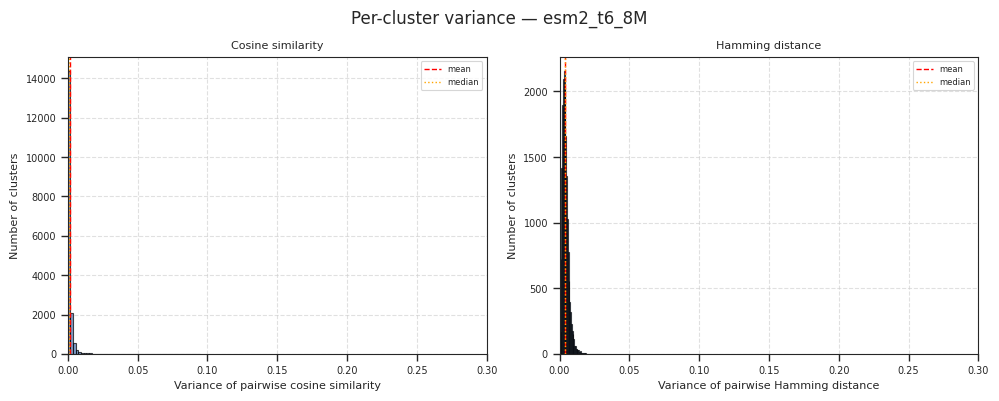

/tmp/ipykernel_1711727/1062197523.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(cos_vals, labels=labels, patch_artist=True)
/tmp/ipykernel_1711727/1062197523.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(ham_vals, labels=labels, patch_artist=True)


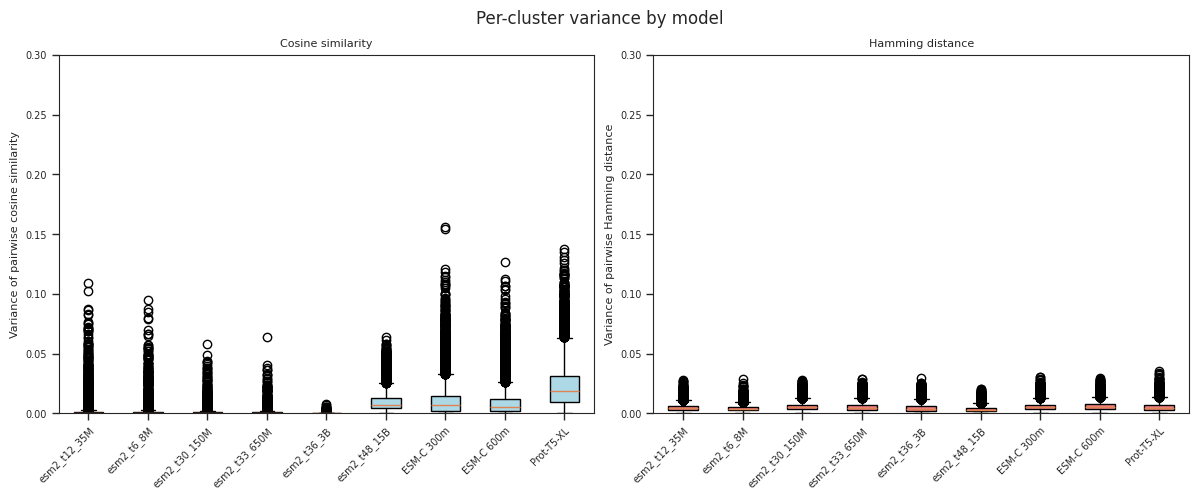

In [9]:
# Edit: path(s) to cluster_variance_*.json
JSON_PATHS = [
    'reports-cluster-variance/seed-42/cluster_variance_esm2_t6_8M_UR50D_seed-42.json',
]
plot_cluster_variance_jupyter(JSON_PATHS)

BASE_DIR = Path("reports-cluster-variance/seed-42")
JSON_PATHS = list(BASE_DIR.glob("*.json"))

plot_cluster_variance_jupyter(JSON_PATHS)